In [89]:
#Churn Analysis using Customer-Churn dataset

#Steps involved in the analysis:
#1. Importing the required libraries
#2. Loading the dataset
#3. Data Cleaning and Preprocessing
#4. Exploratory Data Analysis (EDA)
#5. Feature Engineering
#6. Model Building and Evaluation
#7. Conclusion and Recommendations


In [90]:
#Importing the required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [91]:
#Loading the dataset

df = pd.read_csv('Customer-Churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [92]:
#Data Cleaning and Preprocessing

df.info()
df.describe()
df.isnull().sum()
print("number of missing values in each column:\n", df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [93]:
# Convert 'TotalCharges' to numeric and fill missing values with the mean
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# Fill NaNs in TotalCharges with the column mean to keep all rows
df['TotalCharges'].fillna(df['TotalCharges'].mean(), inplace=True)
print("number of missing values in each column after converting TotalCharges and filling NaNs:
", df.isnull().sum())

SyntaxError: unterminated string literal (detected at line 5) (1739439869.py, line 5)

In [ ]:
# TotalCharges missing values already handled above (filled with mean).
print("number of missing values in each column (verify):

print("number of missing values in each column after handling missing values:\n", df.isnull().sum())  # Checking for missing values again after handling them

number of missing values in each column after handling missing values:
 customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


C:\Users\Divine\AppData\Local\Temp\ipykernel_15192\3745967974.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [94]:
# Verify there are no remaining missing values after TotalCharges fill
print("Missing values per column: ", df.isnull().sum())

# Categorical data explanation:
# Categorical variables take a limited set of discrete values (e.g., gender, Contract, PaymentMethod, Churn).
#categorical data refers to variables that can take on a limited, fixed number of possible values, representing different categories or groups. In the context of the Customer-Churn dataset, categorical columns typically include features such as gender, contract type, payment method, and whether the customer has churned or not. These columns contain discrete values that can be grouped into categories, rather than continuous numerical values.


Missing values per column:  customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


<Axes: xlabel='Churn'>

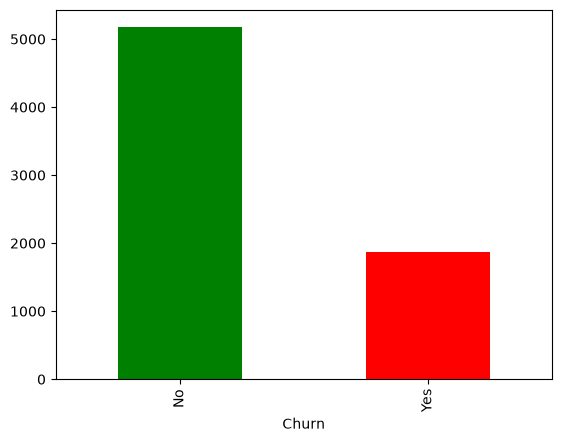

In [95]:
#Exploratory Data Analysis (EDA)

df['Churn'].value_counts().plot(kind='bar', color=['green', 'red'])


<Axes: >

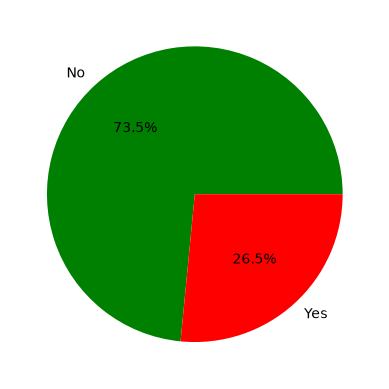

In [96]:
df.title = "Customer Churn Analysis piechart"
df['Churn'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['green', 'red']) 

In [97]:
# Encode target and one-hot encode categorical features (exclude customerID)
# Map target 'Churn' from Yes/No to 1/0
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Identify object (categorical) columns and exclude customerID and Churn
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if 'customerID' in cat_cols:
    cat_cols.remove('customerID')
if 'Churn' in cat_cols:
    cat_cols.remove('Churn')

# One-hot encode categorical columns and drop the first level to avoid multicollinearity
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)


C:\Users\Divine\AppData\Local\Temp\ipykernel_15192\3282884127.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns.tolist()


In [98]:
#dropping irrelevant columns
df.drop(['customerID'], axis=1, inplace=True)  # Dropping the 'customerID' column as it is not relevant for the analysis


In [99]:
#splitting the dataset into training and testing sets for model building and evaluation 
from sklearn.model_selection import train_test_split

X = df.drop(['Churn'], axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [100]:
#Feature Scaling
#It is to improve the performance of the model by scaling the features to a similar range. This is important because features with larger ranges can dominate the learning process and lead to suboptimal model performance.    

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [101]:
#model building and evaluation
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier()
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)


In [103]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy of the Random Forest model: {:.2f}%".format(accuracy * 100))

Accuracy of the Random Forest model: 78.00%


In [104]:
#confusion matrix
import pandas as pd
from sklearn.metrics import confusion_matrix

df_confusion = pd.DataFrame(confusion_matrix(y_test, y_pred), index=['Actual No', 'Actual Yes'], columns=['Predicted No', 'Predicted Yes']) 
print("Confusion Matrix:")
print(df_confusion)


Confusion Matrix:
            Predicted No  Predicted Yes
Actual No            950             91
Actual Yes           219            149


In [ ]:
#Having got model accuracy, You are required to come up with a confusion matrix,precision, recall and F1 score and findout if the model needs more tuning.
#If it needs more tuning, how can this be done